<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_007_aprendizaje_supervisado/_006_07_KNN_Categoricas_OvO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN One-vs-One: combinar 36 modelos para clasificar nueve clases
Se compara **un KNN multiclase** con **36 KNN binarios combinados por votación**, sobre exactamente las mismas muestras de prueba de las nueve categorías. Se mantiene K=101, Jaccard y votos uniformes.

Objetivo: comprobar si OvO mejora el accuracy general. No se presupone que lo hará. Cada modelo por pares vota para todas las muestras de prueba, incluso cuando la clase real no pertenece a ese par. Esto difiere de evaluar cada par solo con sus propias clases.

La implementación OvO es explícita y didáctica; usa KNeighborsClassifier y una regla de desempate documentada. No pretende reproducir exactamente el desempate de `OneVsOneClassifier` de scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from time import perf_counter
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             cohen_kappa_score, ConfusionMatrixDisplay, classification_report)
from IPython.display import display
K = 101
SEMILLA = 17

## 1. Datos y separación
Se incluye la misma copia de `marketing.data` del cuaderno anterior para ejecutar sin conexión. [Fuente original utilizada](https://raw.githubusercontent.com/eduardozurek/ia/refs/heads/main/_007_aprendizaje_supervisado/marketing.data).

Se eliminan filas incompletas como en el ejemplo original. Esto puede introducir sesgo si la ausencia no es aleatoria; imputar dentro del entrenamiento es una alternativa. La primera columna contiene las nueve clases y las otras 13 son características tratadas como nominales.

Dependencias: numpy, pandas, matplotlib, scipy y scikit-learn. Si faltan: `%pip install numpy pandas matplotlib scipy scikit-learn`.

In [2]:
import pandas as pd
#url = "https://web.stanford.edu/~hastie/ElemStatLearn/datasets/marketing.data"
url = "https://raw.githubusercontent.com/eduardozurek/ia/refs/heads/main/_007_aprendizaje_supervisado/marketing.data"
datos = pd.read_csv(url,sep=' ',header=None)

In [3]:
print(f'Filas originales: {len(datos)}; columnas: {datos.shape[1]}')
print(f'Filas con ausencias: {datos.isna().any(axis=1).sum()}')
datos = datos.dropna().reset_index(drop=True)
print(f'Filas completas: {len(datos)}')
X = datos.iloc[:, 1:].to_numpy()
y = datos.iloc[:, 0].to_numpy(dtype=int)
clases = np.unique(y)
assert X.shape[1] == 13 and len(clases) == 9
display(pd.Series(y).value_counts().sort_index().rename('Muestras por clase').to_frame())

Filas originales: 8993; columnas: 14
Filas con ausencias: 2117
Filas completas: 6876


,Muestras por clase
1,1255
2,529
3,505
4,618
5,527
6,846
7,784
8,1069
9,743


In [4]:
it, ip = train_test_split(np.arange(len(y)), test_size=.33,
                          random_state=SEMILLA, stratify=y)
X_train, X_test, y_train, y_test = X[it], X[ip], y[it], y[ip]
clases = np.unique(y_train)
pares_clases = list(combinations(clases, 2))
assert len(pares_clases) == 36
min_entrenamiento_par = min(np.isin(y_train, par).sum() for par in pares_clases)
if K > min_entrenamiento_par:
    raise ValueError(f'K debe ser <= {min_entrenamiento_par}, tamaño del par más pequeño.')
print(f'Entrenamiento: {len(it)}; prueba: {len(ip)}; pares: {len(pares_clases)}')

Entrenamiento: 4606; prueba: 2270; pares: 36


## 2. Misma representación para los dos métodos
Se ajusta **un codificador one-hot completo solo con entrenamiento** y se comparte entre todos los modelos. No se estandarizan las columnas booleanas. Compartir la representación permite atribuir las diferencias al esquema de clasificación, no a codificaciones distintas.

Esta política difiere del análisis anterior, que ajustaba un codificador independiente por tarea. No hay fuga: todas las categorías se aprenden exclusivamente del entrenamiento. Una categoría desconocida en prueba produce un bloque de ceros; se informa su presencia.

Jaccard ignora coincidencias 0–0. Con one-hot completo, cada categoría conocida tiene su propio indicador, incluso para variables binarias.

In [5]:
encoder = OneHotEncoder(drop=None, handle_unknown='ignore',
                        sparse_output=False, dtype=bool)
Xt = encoder.fit_transform(X_train)
Xp = encoder.transform(X_test)
desconocidas = np.column_stack([
    ~np.isin(X_test[:, j], cats) for j, cats in enumerate(encoder.categories_)])
print('Forma de entrenamiento binarizado:', Xt.shape)
print('Filas de prueba con categorías desconocidas:', desconocidas.any(axis=1).sum())

def nuevo_knn():
    return KNeighborsClassifier(n_neighbors=K, weights='uniform',
                                metric='jaccard', algorithm='brute', n_jobs=1)

Forma de entrenamiento binarizado: (4606, 75)
Filas de prueba con categorías desconocidas: 0


## 3. Referencias: multiclase y clase mayoritaria
La referencia mayoritaria aprende la clase más frecuente en entrenamiento. Ambos métodos predicen las nueve clases sobre el mismo conjunto de prueba.

In [6]:
inicio = perf_counter()
modelo_multiclase = nuevo_knn().fit(Xt, y_train)
tiempo_fit_multi = perf_counter()-inicio
inicio = perf_counter()
pred_multi = modelo_multiclase.predict(Xp)
tiempo_pred_multi = perf_counter()-inicio
modelo_dummy = DummyClassifier(strategy='most_frequent').fit(Xt, y_train)
pred_dummy = modelo_dummy.predict(Xp)

## 4. Entrenar los 36 KNN y combinar sus decisiones
Cada modelo conserva solo las filas de entrenamiento de sus dos categorías. Todos usan el mismo K; no se ajusta K mirando la prueba.

Para cada muestra:
1. Cada modelo emite un voto a su clase más probable. Con probabilidades 0.5–0.5 se elige la clase menor, como `argmax` sobre clases ordenadas.
2. Se suman los 36 votos. Cada categoría participa en ocho enfrentamientos, por lo que puede recibir entre 0 y 8 votos.
3. En empate de votos, gana la categoría con mayor **suma de probabilidades de apoyo en sus ocho enfrentamientos**.
4. Si también empatan los apoyos, se elige la primera categoría en orden ascendente.

Se implementa mediante $S_c=V_c+A_c/[3(A_c+1)]$. La corrección está entre 0 y 1/3: nunca revierte una ventaja de un voto y solo resuelve empates.

**Los apoyos y puntuaciones finales no son probabilidades multiclase calibradas.** No se calcula Log loss o Brier aplicándolos directamente a estas puntuaciones. La regla de desempate es una elección explícita y debe fijarse antes de evaluar.

In [7]:
modelos_ovo = []
inicio = perf_counter()
for a, b in pares_clases:
    seleccion = np.isin(y_train, [a, b])
    modelo = nuevo_knn().fit(Xt[seleccion], y_train[seleccion])
    modelos_ovo.append((a, b, modelo))
tiempo_fit_ovo = perf_counter()-inicio

def predecir_ovo(X_binario, devolver_detalle=False):
    votos = np.zeros((len(X_binario), len(clases)), dtype=int)
    apoyos = np.zeros_like(votos, dtype=float)
    posiciones = {clase: i for i, clase in enumerate(clases)}
    probabilidades_pares = []
    ganadores_pares = []
    for a, b, modelo in modelos_ovo:
        p = modelo.predict_proba(X_binario)
        assert np.array_equal(modelo.classes_, [a, b])
        ganador = modelo.classes_[p.argmax(axis=1)]
        ia, ib = posiciones[a], posiciones[b]
        votos[:, ia] += ganador == a
        votos[:, ib] += ganador == b
        apoyos[:, ia] += p[:, 0]
        apoyos[:, ib] += p[:, 1]
        if devolver_detalle:
            probabilidades_pares.append(p)
            ganadores_pares.append(ganador)
    puntuaciones = votos + apoyos/(3*(apoyos+1))
    pred = clases[puntuaciones.argmax(axis=1)]
    assert np.all(votos.sum(axis=1) == len(modelos_ovo))
    assert np.all(votos <= len(clases)-1)
    assert np.allclose(apoyos.sum(axis=1), len(modelos_ovo))
    # La clase elegida siempre tiene el número máximo de votos.
    assert np.all(votos[np.arange(len(pred)), puntuaciones.argmax(axis=1)] == votos.max(axis=1))
    if devolver_detalle:
        return pred, votos, apoyos, puntuaciones, probabilidades_pares, ganadores_pares
    return pred

inicio = perf_counter()
(pred_ovo, votos, apoyos, puntuaciones,
 probabilidades_pares, ganadores_pares) = predecir_ovo(Xp, devolver_detalle=True)
tiempo_pred_ovo = perf_counter()-inicio
empates = (votos == votos.max(axis=1, keepdims=True)).sum(axis=1) > 1
print(f'Muestras con empate en el máximo de votos: {empates.sum()} / {len(y_test)}')

Muestras con empate en el máximo de votos: 30 / 2270


## 5. Comparación sobre la misma prueba de nueve clases
Se reportan accuracy, balanced accuracy (recall medio por clase), F1 macro y Kappa. Los tiempos son orientativos y dependen del equipo. Esta medición incluye el detalle de votación en OvO.

La diferencia se expresa en **puntos porcentuales**, no como mejora relativa. Un resultado mayor en una única partición no demuestra una mejora estable.

,Accuracy,Balanced accuracy,F1 macro,Kappa
Mayoritaria,0.1824,0.1111,0.0343,0.0000
KNN multiclase,0.3476,0.2720,0.2503,0.2399
KNN OvO,0.3317,0.2511,0.2145,0.2157


,Ajuste (s),Predicción (s)
KNN multiclase,0.004,4.778
KNN OvO,0.110,27.072


Diferencia de accuracy (OvO − multiclase): -1.59 puntos porcentuales
OvO empeora en esta partición.


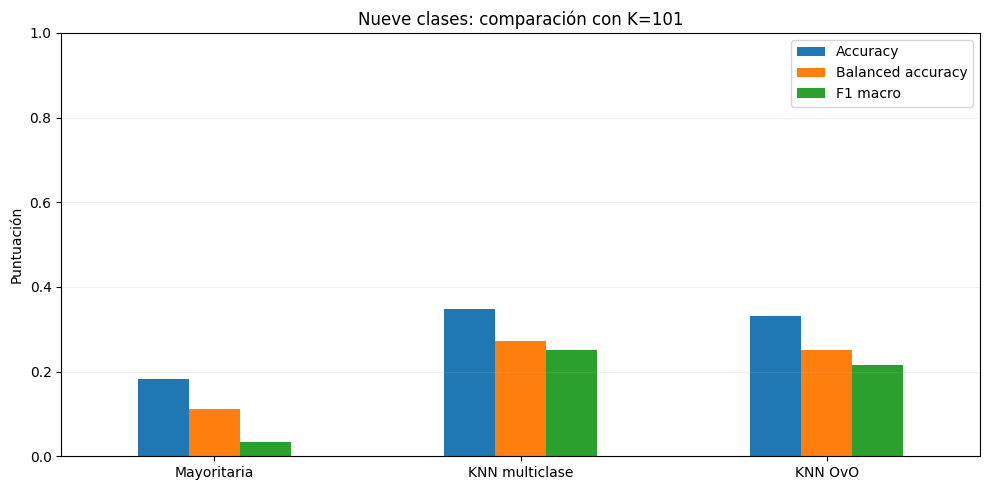

In [8]:
def evaluar(pred):
    return {'Accuracy': accuracy_score(y_test, pred),
            'Balanced accuracy': balanced_accuracy_score(y_test, pred),
            'F1 macro': f1_score(y_test, pred, average='macro', zero_division=0),
            'Kappa': cohen_kappa_score(y_test, pred)}
resultados = pd.DataFrame({
    'Mayoritaria': evaluar(pred_dummy),
    'KNN multiclase': evaluar(pred_multi),
    'KNN OvO': evaluar(pred_ovo)
}).T
display(resultados.round(4))
display(pd.DataFrame({'Ajuste (s)': [tiempo_fit_multi, tiempo_fit_ovo],
                      'Predicción (s)': [tiempo_pred_multi, tiempo_pred_ovo]},
                     index=['KNN multiclase', 'KNN OvO']).round(3))
diferencia = 100*(resultados.loc['KNN OvO', 'Accuracy']-resultados.loc['KNN multiclase', 'Accuracy'])
print(f'Diferencia de accuracy (OvO − multiclase): {diferencia:+.2f} puntos porcentuales')
print('OvO mejora en esta partición.' if diferencia > 0 else
      'OvO empeora en esta partición.' if diferencia < 0 else 'Empate de accuracy en esta partición.')
resultados[['Accuracy', 'Balanced accuracy', 'F1 macro']].plot.bar(figsize=(10, 5), rot=0)
plt.ylim(0, 1)
plt.ylabel('Puntuación')
plt.title(f'Nueve clases: comparación con K={K}')
plt.grid(axis='y', alpha=.2)
plt.tight_layout()
plt.show()

## 6. Qué errores cambia OvO
Se comparan las predicciones muestra a muestra. Corregir algunos errores no basta: OvO también puede convertir aciertos del modelo multiclase en errores.

,Situación,Muestras
0,Ambos aciertan,661
1,Solo multiclase acierta,128
2,Solo OvO acierta,92
3,Ambos fallan,1389


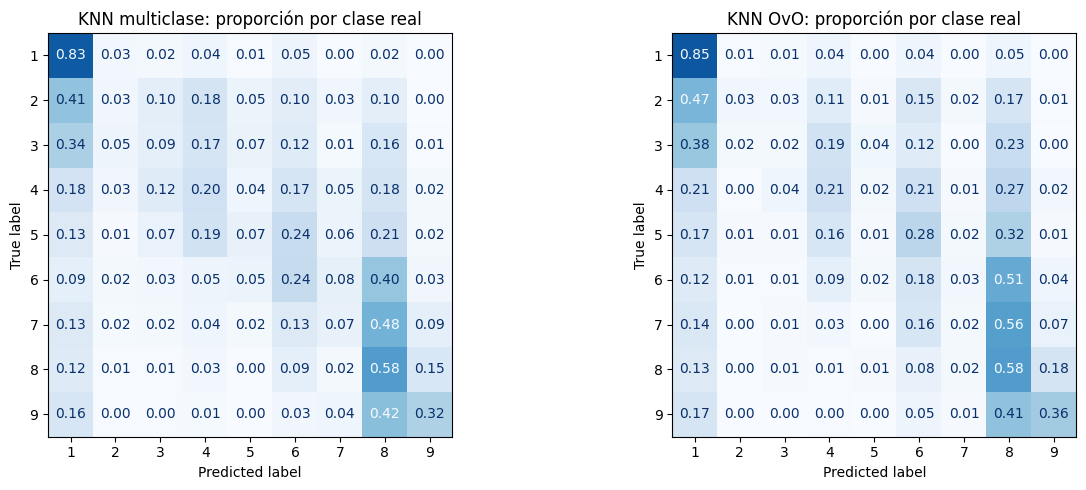

Informe por clase: OvO
              precision    recall  f1-score   support

           1     0.4842    0.8502    0.6170       414
           2     0.3333    0.0343    0.0622       175
           3     0.0938    0.0180    0.0302       167
           4     0.2428    0.2059    0.2228       204
           5     0.0870    0.0115    0.0203       174
           6     0.1754    0.1792    0.1773       279
           7     0.1613    0.0193    0.0345       259
           8     0.2576    0.5779    0.3563       353
           9     0.4709    0.3633    0.4101       245

    accuracy                         0.3317      2270
   macro avg     0.2562    0.2511    0.2145      2270
weighted avg     0.2802    0.3317    0.2665      2270



In [9]:
acierto_multi = pred_multi == y_test
acierto_ovo = pred_ovo == y_test
cambios = pd.DataFrame([
    ['Ambos aciertan', np.sum(acierto_multi & acierto_ovo)],
    ['Solo multiclase acierta', np.sum(acierto_multi & ~acierto_ovo)],
    ['Solo OvO acierta', np.sum(~acierto_multi & acierto_ovo)],
    ['Ambos fallan', np.sum(~acierto_multi & ~acierto_ovo)]
], columns=['Situación', 'Muestras'])
display(cambios)
assert cambios['Muestras'].sum() == len(y_test)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, nombre, pred in zip(axes, ['KNN multiclase', 'KNN OvO'], [pred_multi, pred_ovo]):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=clases,
        normalize='true', values_format='.2f', cmap='Blues', ax=ax,
        colorbar=False, im_kw={'vmin': 0, 'vmax': 1})
    ax.set_title(nombre + ': proporción por clase real')
fig.tight_layout()
plt.show()
print('Informe por clase: OvO')
print(classification_report(y_test, pred_ovo, digits=4, zero_division=0))

## 7. Votación paso a paso de una muestra
Cambie `INDICE_MUESTRA` para examinar otra fila de prueba. La tabla muestra las 36 decisiones, incluso de modelos que no contienen la categoría real. La segunda tabla explica la agregación; no se interpreta el apoyo como probabilidad final.

Fila original de casos completos: 6555
Clase real: 8; multiclase: 9; OvO: 9


,Clase A,Clase B,P(A | par),P(B | par),Voto para,Incluye clase real
0,1,2,0.5347,0.4653,1,False
1,1,3,0.4257,0.5743,3,False
2,1,4,0.1782,0.8218,4,False
3,1,5,0.2079,0.7921,5,False
4,1,6,0.0198,0.9802,6,False
5,1,7,0.0000,1.0000,7,False
6,1,8,0.0000,1.0000,8,True
7,1,9,0.0000,1.0000,9,False
8,2,3,0.4059,0.5941,3,False
9,2,4,0.2475,0.7525,4,False


,Clase,Votos,Apoyo,Puntuación
8,9,8,7.4158,8.2937
7,8,7,6.7723,7.2904
6,7,6,5.6139,6.2829
5,6,5,4.9010,5.2768
4,5,4,3.3069,4.2559
3,4,3,3.2079,3.2541
2,3,2,1.9604,2.2207
0,1,1,1.3663,1.1925
1,2,0,1.4554,0.1976


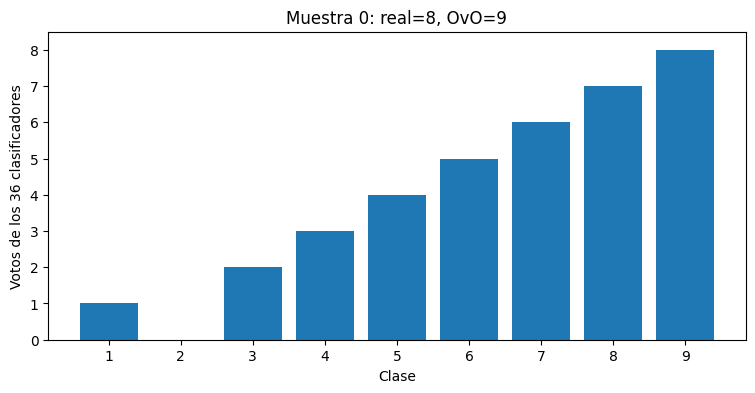

In [10]:
INDICE_MUESTRA = 0
q = INDICE_MUESTRA
if not 0 <= q < len(y_test):
    raise ValueError('Índice de muestra fuera de rango.')
print(f'Fila original de casos completos: {ip[q]}')
print(f'Clase real: {y_test[q]}; multiclase: {pred_multi[q]}; OvO: {pred_ovo[q]}')
filas = []
for t, (a, b, _) in enumerate(modelos_ovo):
    filas.append({'Clase A': a, 'Clase B': b,
                  'P(A | par)': probabilidades_pares[t][q, 0],
                  'P(B | par)': probabilidades_pares[t][q, 1],
                  'Voto para': ganadores_pares[t][q],
                  'Incluye clase real': y_test[q] in [a, b]})
with pd.option_context('display.max_rows', 40):
    display(pd.DataFrame(filas).round(4))
detalle = pd.DataFrame({'Clase': clases, 'Votos': votos[q],
                       'Apoyo': apoyos[q], 'Puntuación': puntuaciones[q]})
display(detalle.sort_values(['Puntuación', 'Clase'], ascending=[False, True]).round(4))
plt.figure(figsize=(9, 4))
plt.bar(clases, votos[q])
plt.xticks(clases)
plt.ylim(0, len(clases)-1+.5)
plt.xlabel('Clase')
plt.ylabel('Votos de los 36 clasificadores')
plt.title(f'Muestra {q}: real={y_test[q]}, OvO={pred_ovo[q]}')
plt.show()

## Interpretación y siguientes experimentos
- Un buen accuracy de 1–9 en su propio subconjunto no garantiza buen accuracy de nueve clases: aquí cada muestra recibe las 36 decisiones.
- La referencia multiclase y OvO usan los mismos datos, K, distancia, pesos y codificación. Cambia qué ejemplos participan en cada búsqueda y cómo se agregan decisiones.
- La regla de desempate forma parte del modelo. No debe cambiarse repetidamente para mejorar esta prueba.
- El resultado depende de K y de la partición. Para elegir K, use validación cruzada solo sobre entrenamiento, reajustando el codificador dentro de cada fold. Compare luego ambos métodos seleccionados en una prueba independiente.
- Puede optimizarse un K común para el sistema OvO completo o un K por par. Son diseños distintos; optimizar cada par por separado no garantiza mejorar la votación global.
- Este conjunto de prueba ya se ha explorado en otros cuadernos: la comparación es didáctica, no una confirmación final independiente de decisiones tomadas durante esa exploración.
- Ajustar 36 modelos aumenta el coste y repite muestras: cada ejemplo de entrenamiento pertenece a ocho modelos. Observe los tiempos medidos, no suponga una aceleración.
